# Retrieval augmented generation
 
- In retrieval augmented generation (RAG), an LLM retrieves contextual documents from an external dataset as part of its execution. 

This is useful if we want to ask question about specific documents (e.g., our PDFs, a set of videos, etc). 

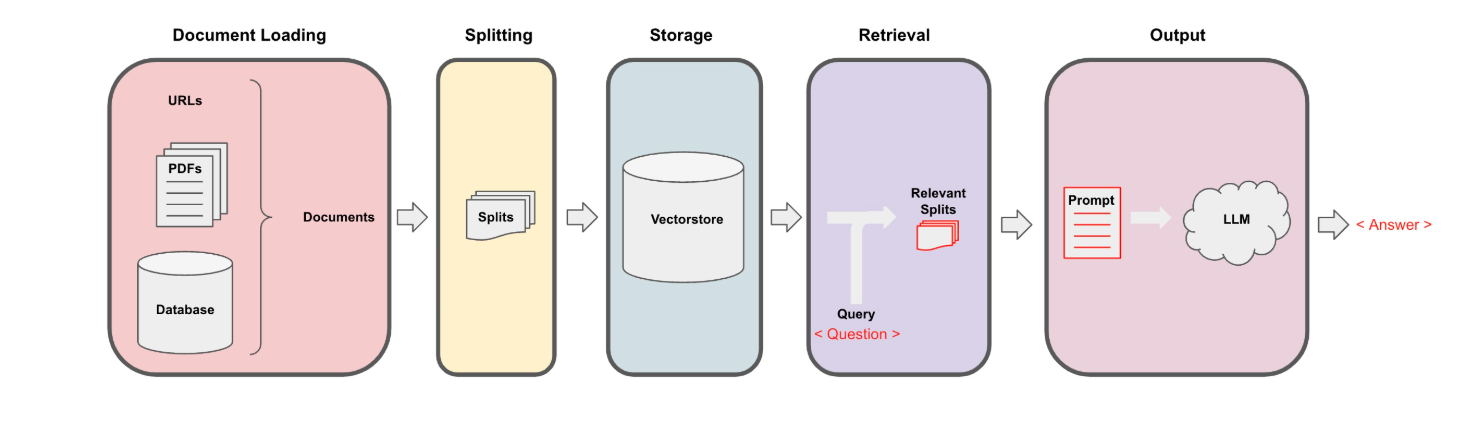

# 1. Document Loading

### PDF LOADING

In [1]:
#! pip install langchain
#! pip install pypdf 

In [2]:
from langchain.document_loaders import PyPDFLoader

# Load PDF
loaders = [
    # Duplicate documents on purpose - messy data
    PyPDFLoader("MachineLearning-Lecture01.pdf"),
    PyPDFLoader("MachineLearning-Lecture03.pdf"),
    PyPDFLoader("MachineLearning-Lecture02.pdf")
]
docs = []
for loader in loaders:
    docs.extend(loader.load())

In [3]:
# docs
len(docs)

56

In [4]:
page = docs[0]
page

Document(metadata={'producer': 'Acrobat Distiller 8.1.0 (Windows)', 'creator': 'PScript5.dll Version 5.2.2', 'creationdate': '2008-07-11T11:25:23-07:00', 'author': '', 'moddate': '2008-07-11T11:25:23-07:00', 'title': '', 'source': 'MachineLearning-Lecture01.pdf', 'total_pages': 22, 'page': 0, 'page_label': '1'}, page_content='MachineLearning-Lecture01  \nInstructor (Andrew Ng): Okay. Good morning. Welcome to CS229, the machine \nlearning class. So what I wanna do today is just spend a little time going over the logistics \nof the class, and then we\'ll start to talk a bit about machine learning.  \nBy way of introduction, my name\'s Andrew Ng and I\'ll be instructor for this class. And so \nI personally work in machine learning, and I\'ve worked on it for about 15 years now, and \nI actually think that machine learning is the most exciting field of all the computer \nsciences. So I\'m actually always excited about teaching this class. Sometimes I actually \nthink that machine learning 

In [5]:
page.metadata

{'producer': 'Acrobat Distiller 8.1.0 (Windows)',
 'creator': 'PScript5.dll Version 5.2.2',
 'creationdate': '2008-07-11T11:25:23-07:00',
 'author': '',
 'moddate': '2008-07-11T11:25:23-07:00',
 'title': '',
 'source': 'MachineLearning-Lecture01.pdf',
 'total_pages': 22,
 'page': 0,
 'page_label': '1'}

In [6]:
page.page_content

'MachineLearning-Lecture01  \nInstructor (Andrew Ng): Okay. Good morning. Welcome to CS229, the machine \nlearning class. So what I wanna do today is just spend a little time going over the logistics \nof the class, and then we\'ll start to talk a bit about machine learning.  \nBy way of introduction, my name\'s Andrew Ng and I\'ll be instructor for this class. And so \nI personally work in machine learning, and I\'ve worked on it for about 15 years now, and \nI actually think that machine learning is the most exciting field of all the computer \nsciences. So I\'m actually always excited about teaching this class. Sometimes I actually \nthink that machine learning is not only the most exciting thing in computer science, but \nthe most exciting thing in all of human endeavor, so maybe a little bias there.  \nI also want to introduce the TAs, who are all graduate students doing research in or \nrelated to the machine learning and all aspects of machine learning. Paul Baumstarck \nworks i

# 2. Splitting

**OTHER SPLITTING**
- context aware and token splitting

Here are some common text splitters and when to use them:

1. **CharacterTextSplitter**: Use when you want to split text into fixed-size chunks based on character length.

2. **RecursiveCharacterTextSplitter**: Use when you need to split text recursively using multiple delimiters, ensuring chunks are within a specified size but respect natural breaks (like paragraphs and sentences).

3. **SentenceSplitter**: Use when you want to split text into individual sentences.

4. **DocumentSplitter**: Use when splitting entire documents into smaller sections or chunks while keeping structure intact.

5. **ChunkTextSplitter**: Use when you need to split text into chunks based on a specified size without breaking words.

6. **WhitespaceTextSplitter**: Use when you want to split the text based on spaces (i.e., by words or phrases).

7. **LineTextSplitter**: Use when splitting by lines, commonly used with line-by-line text formats like CSV or logs.

8. **RegexTextSplitter**: Use when you want to split text using custom regular expressions.

Each splitter serves a specific use case, depending on whether you want fine-grained control over chunk size, sentence or word boundaries, or specific patterns.

# 3 Vectorstores and Embeddings

Recall the overall workflow for retrieval augmented generation (RAG):

* w ewill be doing embedding and generation from locally avaliable ollama models

### Applying recursive text splitter

In [7]:
# Split
from langchain.text_splitter import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1500,
    chunk_overlap = 150
)

splits = text_splitter.split_documents(docs)

len(splits)

151

### Embeddings

In [11]:
# !pip install langchain_ollama

In [12]:
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(model="mxbai-embed-large")

### Vectorstore

#### Etiher of it can be used

In [13]:
# from langchain_chroma import Chroma

# vector_store = Chroma(embedding_function=embeddings,persist_directory='li')
# ids = vector_store.add_documents(documents=splits)
# # ids

In [14]:
from langchain.vectorstores import Chroma
persist_directory = 'sunday2/chroma/'
vectordb = Chroma.from_documents(
    documents=splits,
    embedding=embeddings,
    persist_directory=persist_directory
)

In [15]:
print(vectordb._collection.count())

302


### Similarity search

In [16]:
vectordb.similarity_search('who is the instructor of the class?',k=3)[0]

Document(metadata={'author': '', 'creationdate': '2008-07-11T11:25:05-07:00', 'creator': 'PScript5.dll Version 5.2.2', 'moddate': '2008-07-11T11:25:05-07:00', 'page': 0, 'page_label': '1', 'producer': 'Acrobat Distiller 8.1.0 (Windows)', 'source': 'MachineLearning-Lecture02.pdf', 'title': '', 'total_pages': 18}, page_content="MachineLearning-Lecture02  \nInstructor (Andrew Ng):All right, good morning, welcome back. So before we jump \ninto today's material, I just have one administrative announcement, which is graders. So I \nguess sometime next week, we'll hand out the first homework assignment for this class.  \nIs this loud enough, by the way? Can people in the back hear me? No. Can you please \nturn up the mic a bit louder? Is this better? Is this okay? This is okay? Great.  \nSo sometime next week, we'll hand out the first problem sets and it'll be two weeks after \nthat, and the way we grade homework problems in this class is by some combination of \nTAs and graders, where grader

In [17]:
vectordb.similarity_search('who is the instructor of the class?',k=3)[0]

Document(metadata={'author': '', 'creationdate': '2008-07-11T11:25:05-07:00', 'creator': 'PScript5.dll Version 5.2.2', 'moddate': '2008-07-11T11:25:05-07:00', 'page': 0, 'page_label': '1', 'producer': 'Acrobat Distiller 8.1.0 (Windows)', 'source': 'MachineLearning-Lecture02.pdf', 'title': '', 'total_pages': 18}, page_content="MachineLearning-Lecture02  \nInstructor (Andrew Ng):All right, good morning, welcome back. So before we jump \ninto today's material, I just have one administrative announcement, which is graders. So I \nguess sometime next week, we'll hand out the first homework assignment for this class.  \nIs this loud enough, by the way? Can people in the back hear me? No. Can you please \nturn up the mic a bit louder? Is this better? Is this okay? This is okay? Great.  \nSo sometime next week, we'll hand out the first problem sets and it'll be two weeks after \nthat, and the way we grade homework problems in this class is by some combination of \nTAs and graders, where grader

In [18]:
vectordb.similarity_search('what is machine learning?',k=1)

[Document(metadata={'author': '', 'creationdate': '2008-07-11T11:25:23-07:00', 'creator': 'PScript5.dll Version 5.2.2', 'moddate': '2008-07-11T11:25:23-07:00', 'page': 10, 'page_label': '11', 'producer': 'Acrobat Distiller 8.1.0 (Windows)', 'source': 'MachineLearning-Lecture01.pdf', 'title': '', 'total_pages': 22}, page_content='very excited about the new projector in this room, but I guess we\'ll see that in operation \non Wednesday.  \nSo start by talking about what machine learning is. What is machine learning? Actually, \ncan you read the text out there? Raise your hand if the text on the small screens is legible. \nOh, okay, cool, mostly legible. Okay. So I\'ll just read it out.  \nSo what is machine learning? Way back in about 1959, Arthur Samuel defined machine \nlearning informally as the [inaudible] that gives computers to learn — [inaudible] that \ngives computers the ability to learn without being explicitly programmed. So Arthur \nSamuel, so way back in the history of machi

In [19]:
vectordb.similarity_search('what are the algorithms discussed',k=3)

[Document(metadata={'author': '', 'creationdate': '2008-07-11T11:25:23-07:00', 'creator': 'PScript5.dll Version 5.2.2', 'moddate': '2008-07-11T11:25:23-07:00', 'page': 3, 'page_label': '4', 'producer': 'Acrobat Distiller 8.1.0 (Windows)', 'source': 'MachineLearning-Lecture01.pdf', 'title': '', 'total_pages': 22}, page_content="So, see, most of us use learning algorithms half a dozen, a dozen, maybe dozens of times \nwithout even knowing it.  \nAnd of course, learning algorithms are also doing things like giving us a growing \nunderstanding of the human genome. So if someday we ever find a cure for cancer, I bet \nlearning algorithms will have had a large role in that. That's sort of the thing that Tom \nworks on, yes?  \nSo in teaching this class, I sort of have three goals. One of them is just to I hope convey \nsome of my own excitement about machine learning to you.  \nThe second goal is by the end of this class, I hope all of you will be able to apply state-of-\nthe-art machine lea

**MMR** is a search approach that balances relevance to the query with diversity in the results to reduce redundancy and provide a more comprehensive set of results.

In [20]:
vectordb.max_marginal_relevance_search('what are the algorithms discussed',k=3)

[Document(metadata={'author': '', 'creationdate': '2008-07-11T11:25:23-07:00', 'creator': 'PScript5.dll Version 5.2.2', 'moddate': '2008-07-11T11:25:23-07:00', 'page': 3, 'page_label': '4', 'producer': 'Acrobat Distiller 8.1.0 (Windows)', 'source': 'MachineLearning-Lecture01.pdf', 'title': '', 'total_pages': 22}, page_content="So, see, most of us use learning algorithms half a dozen, a dozen, maybe dozens of times \nwithout even knowing it.  \nAnd of course, learning algorithms are also doing things like giving us a growing \nunderstanding of the human genome. So if someday we ever find a cure for cancer, I bet \nlearning algorithms will have had a large role in that. That's sort of the thing that Tom \nworks on, yes?  \nSo in teaching this class, I sort of have three goals. One of them is just to I hope convey \nsome of my own excitement about machine learning to you.  \nThe second goal is by the end of this class, I hope all of you will be able to apply state-of-\nthe-art machine lea

# Question answering

In [21]:
import warnings
warnings.filterwarnings("ignore")

In [22]:
from langchain.llms import Ollama

In [23]:
llm = Ollama(model="llama3.2", temperature=0)


In [24]:
from langchain.chains import RetrievalQA

In [25]:
qa_chain = RetrievalQA.from_chain_type(
    llm,
    retriever=vectordb.as_retriever(search_type="mmr")
)

In [26]:
question = "What are major topics for this class?"

In [27]:
result = qa_chain({"query": question})

In [28]:
result["result"]

'Based on the provided context, it appears that the class is likely CS229, a machine learning course at Stanford University. The instructor mentions that the class will cover extensions for material taught in main lectures and assumes familiarity with basic probability and statistics, as well as linear algebra.\n\nThe major topics for this class are not explicitly stated, but based on the context, it can be inferred that they may include:\n\n* Machine learning\n* Extensions to material covered in main lectures (likely related to machine learning)\n* Probability and statistics\n* Linear algebra\n\nIt is also mentioned that the class will have a midterm, an open assignment, and a term project, which suggests that the topics may be organized around these assignments. However, without further information, it is difficult to provide a more specific answer.'

In [29]:
result = qa_chain({"query": "who is the instructor of the class?"})
result["result"]

'The instructor of the class is Andrew Ng.'

In [30]:
result = qa_chain({"query": "what is the capital of India?"})
result["result"]

"I don't know the answer to that question. The conversation appears to be about a machine learning class at Stanford University, and there is no mention of geography or politics."

In [31]:
question="is probablity a topic of the class?"

In [32]:
result = qa_chain({"query": question})

In [33]:
result["result"]

'Yes, probability appears to be a topic covered in this class, as indicated by the instructor mentioning "basic probability and statistics" as prerequisites for the course. Additionally, the discussion about measuring likelihood and error suggests that probability concepts will be explored further in the class.'

In [34]:
question = "what are the prerequisite for it?"

In [35]:
result = qa_chain({"query": question})
result["result"]

"I don't know the specific prerequisites for CS229. The text mentions that the instructor assumes all students have knowledge of big O notation, data structures like queues, stacks, and binary trees, as well as basic programming skills, but it does not explicitly state what courses or topics are required before taking this class."

**Unable** to gnenerate respomses based on previous question

# Chat

In [36]:
# Build prompt
from langchain.prompts import PromptTemplate
template = """Use the following pieces of context to answer the question at the end. If you don't know the answer, 
just say that you don't know, don't try to make up an answer. 
Use three sentences maximum. Keep the answer as concise as possible. Always say "thanks for asking!" at the end of the answer. 
{context}
Question: {question}
Helpful Answer:"""

QA_CHAIN_PROMPT = PromptTemplate(input_variables=["context", "question"],template=template,)

# Run chain
from langchain.chains import RetrievalQA
qa_chain = RetrievalQA.from_chain_type(llm,
                                       retriever=vectordb.as_retriever(),
                                       return_source_documents=True,
                                       chain_type_kwargs={"prompt": QA_CHAIN_PROMPT})



question = "Is probability a class topic?"
result = qa_chain({"query": question})
result["result"]

'Yes, probability is mentioned as one of the topics to be covered in the class, specifically in relation to machine learning and statistics. It is also assumed that students have a basic understanding of probability and statistics from their previous education. \n\nThanks for asking!'

### Memory

In [37]:
from langchain.memory import ConversationBufferMemory
memory = ConversationBufferMemory(
    memory_key="chat_history",
    return_messages=True
)

### Conversational chat history

In [38]:
from langchain.chains import ConversationalRetrievalChain
qa = ConversationalRetrievalChain.from_llm(
    llm,
    retriever=vectordb.as_retriever(),
    memory=memory
)

In [39]:
question = "what are classfication algorithms discussed in lectures?"
result = qa({"question": question})
result['answer']

"Based on the provided context, classification algorithms mentioned or implied to be discussed in the lectures include:\n\n1. Logistic Regression\n2. Perceptron Algorithm (mentioned as a digression and will be covered later)\n3. Newton's Method for fitting logistic regression models (also mentioned as a future topic)\n\nNote that locally weighted regression is also mentioned, but it seems to be an adaptation of linear regression rather than a classification algorithm itself."

In [40]:
question = "what does it say about the first one"
result = qa({"question": question})
result['answer']

"Based on the provided context, it appears that logistic regression is mentioned as the first classification algorithm that will be covered after discussing locally weighted regression and before diving into other topics such as Newton's method. Additionally, there is a brief mention of the perceptron algorithm, which seems to be related to logistic regression, but its connection is not explicitly stated in this context."

In [41]:
question = "does the lecture explain the third algorithm  you mentioned in previous question?"
result = qa({"question": question})
result['answer']

'No, the lecture does not cover Newton\'s Method for fitting logistic regression models. The instructor mentions that they "probably won\'t get to Newton’s Method today" and only briefly mention it as something they hope to cover later in the quarter.'